# LogPress

### Data Loading

Load all log datasets and examine their formats.

In [1]:
# Library imports
import re
import time
from pathlib import Path
from collections import Counter
from datetime import datetime

try:
    import pandas as pd
    import matplotlib.pyplot as plt
    import numpy as np
    import gzip
    import bz2
    import lzma
    import msgpack
    import zstandard as zstd

except ImportError:
    print("Installing dependencies...")
    %pip install pandas numpy matplotlib msgpack zstandard
    import pandas as pd
    import matplotlib.pyplot as plt
    import numpy as np
    import msgpack
    import zstandard as zstd
print("All libraries loaded.")

All libraries loaded.


In [2]:
# Dataset paths
DATASETS_DIR = Path("datasets")

DATASET_FILES = {
    "Apache": DATASETS_DIR / "Apache.log",
    #"BGL": DATASETS_DIR / "BGL.log",
    "Hadoop": DATASETS_DIR / "Hadoop.log",
    #"HDFS": DATASETS_DIR / "HDFS.log",
    "HealthApp": DATASETS_DIR / "HealthApp.log",
    "Linux": DATASETS_DIR / "Linux.log",
    "Mac": DATASETS_DIR / "Mac.log",
    "OpenSSH": DATASETS_DIR / "OpenSSH.log",
    "Openstack": DATASETS_DIR / "Openstack.log",
    #"Spark": DATASETS_DIR / "Spark.log",
    "Proxifier": DATASETS_DIR / "Proxifier.log",
    "Zookeeper": DATASETS_DIR / "Zookeeper.log",
}

# Verify all files exist
for name, path in DATASET_FILES.items():
    if path.exists():
        print(f"{name}: {path} (EXISTS)")
    else:
        print(f"{name}: {path} (MISSING)")

Apache: datasets/Apache.log (EXISTS)
Hadoop: datasets/Hadoop.log (EXISTS)
HealthApp: datasets/HealthApp.log (EXISTS)
Linux: datasets/Linux.log (EXISTS)
Mac: datasets/Mac.log (EXISTS)
OpenSSH: datasets/OpenSSH.log (EXISTS)
Openstack: datasets/Openstack.log (EXISTS)
Proxifier: datasets/Proxifier.log (EXISTS)
Zookeeper: datasets/Zookeeper.log (EXISTS)


In [3]:
# Functions to use in data loading
def load_logs(filepath):
    logs = []
    with open(filepath, "r", encoding="utf-8", errors="replace") as f:
        for line in f:
            line = line.rstrip("\n\r")
            if line:  # skip empty lines
                logs.append(line)
    return logs


def get_file_size_mb(filepath):
    return filepath.stat().st_size / (1024 * 1024)

In [4]:
# Load all datasets
datasets = {}

print("Loading datasets...\n")
print(f"{'Dataset':<12} {'Lines':>12} {'Size (MB)':>12}")
print("-" * 40)

total_lines = 0
total_size = 0

for name, path in DATASET_FILES.items():
    start = time.time()
    logs = load_logs(path)
    elapsed = time.time() - start
    
    size_mb = get_file_size_mb(path)
    datasets[name] = logs
    
    total_lines += len(logs)
    total_size += size_mb
    
    print(f"{name:<12} {len(logs):>12,} {size_mb:>12.1f}")

print("-" * 40)
print(f"{'TOTAL':<12} {total_lines:>12,} {total_size:>12.1f}")
print("\nAll datasets loaded.")

Loading datasets...

Dataset             Lines    Size (MB)
----------------------------------------
Apache             51,978          4.7
Hadoop            179,993         30.4
HealthApp         253,395         22.4
Linux              25,567          2.2
Mac               117,283         16.1
OpenSSH           638,947         67.3
Openstack         189,386         53.4
Proxifier          21,320          2.4
Zookeeper          74,273          9.9
----------------------------------------
TOTAL           1,552,142        208.9

All datasets loaded.


In [5]:
# Preview first 3 logs from each dataset we loaded
print("Log Format Samples\n")

for name, logs in datasets.items():
    print(f"=== {name} ===")
    for i in range(min(3, len(logs))):
        # Truncate long lines for display
        line = logs[i]
        if len(line) > 120:
            line = line[:120] + "..."
        print(f"  {line}")
    print()

Log Format Samples

=== Apache ===
  [Thu Jun 09 06:07:04 2005] [notice] LDAP: Built with OpenLDAP LDAP SDK
  [Thu Jun 09 06:07:04 2005] [notice] LDAP: SSL support unavailable
  [Thu Jun 09 06:07:04 2005] [notice] suEXEC mechanism enabled (wrapper: /usr/sbin/suexec)

=== Hadoop ===
  2015-10-17 21:48:16,337 INFO [main] org.apache.hadoop.metrics2.impl.MetricsConfig: loaded properties from hadoop-metrics...
  2015-10-17 21:48:16,509 INFO [main] org.apache.hadoop.metrics2.impl.MetricsSystemImpl: Scheduled snapshot period at 10 s...
  2015-10-17 21:48:16,509 INFO [main] org.apache.hadoop.metrics2.impl.MetricsSystemImpl: MapTask metrics system started

=== HealthApp ===
  20171223-22:15:29:606|Step_LSC|30002312|onStandStepChanged 3579
  20171223-22:15:29:615|Step_LSC|30002312|onExtend:1514038530000 14 0 4
  20171223-22:15:29:633|Step_StandReportReceiver|30002312|onReceive action: android.intent.action.SCREEN_ON

=== Linux ===
  Jun  9 06:06:20 combo syslogd 1.4.1: restart.
  Jun  9 06:06:20

In [6]:
# Statistics per dataset
stats = []

for name, logs in datasets.items():
    lengths = [len(log) for log in logs]
    stats.append({
        "Dataset": name,
        "Log Count": len(logs),
        "Min Length": min(lengths),
        "Max Length": max(lengths),
        "Avg Length": round(sum(lengths) / len(lengths), 1),
        "Total Chars": sum(lengths),
    })

stats_df = pd.DataFrame(stats)
print(stats_df.to_string(index=False))

  Dataset  Log Count  Min Length  Max Length  Avg Length  Total Chars
   Apache      51978          48         187        94.7      4923706
   Hadoop     179993          65         592       176.2     31707290
HealthApp     253395          48         294        90.9     23023140
    Linux      25567          29        1030        90.9      2324119
      Mac     117283           1        1314       141.8     16634140
  OpenSSH     638947          65         188       109.4     69897118
Openstack     189386         100         450       294.7     55816574
Proxifier      21320          91         224       117.2      2498071
Zookeeper      74273          75         387       138.1     10256034


### Section 2: Tokenization

Split logs into tokens. 
Tokenizer will handle those delimiters ( Spaces, Brackets [] () , Pipes | , Colons : , Equals = ).
Count Token Frequency and Distribution per dataset.

In [7]:
# Tokenization Function with Separators
def tokenize_with_separators(log):

    tokens = []
    separators = []
    current_token = ""
    current_sep = ""
    
    bracket_delims = "[](){}"
    symbol_delims = "|:=,"
    whitespace = " \t"
    
    for char in log:
        if char in whitespace:
            if current_token:
                tokens.append(current_token)
                separators.append(current_sep)
                current_token = ""
                current_sep = char
            else:
                current_sep += char
        elif char in bracket_delims or char in symbol_delims:
            if current_token:
                tokens.append(current_token)
                separators.append(current_sep)
                current_token = ""
                current_sep = ""
            tokens.append(char)
            separators.append(current_sep)
            current_sep = ""
        else:
            current_token += char
    
    if current_token:
        tokens.append(current_token)
        separators.append(current_sep)
    
    return tokens, separators


In [8]:
# Reconstruction Function
def reconstruct_from_tokens_and_separators(tokens, separators):

    result = []
    for i, token in enumerate(tokens):
        if i < len(separators):
            result.append(separators[i])
        result.append(token)
    return "".join(result)

In [9]:
# Tokenize all unstructured logs
tokenized_datasets = {}
separator_datasets = {} # store separators for reconstruction

print("Tokenizing all datasets...\n")
print(f"{'Dataset':<12} {'Logs':>12} {'Total Tokens':>15} {'Avg Tokens/Log':>15}")
print("-" * 58)

for name, logs in datasets.items():
    start = time.time()
    tokenized_logs = []
    separator_logs = []
    
    for log in logs:
        tokens, separators = tokenize_with_separators(log)
        tokenized_logs.append(tokens)
        separator_logs.append(separators)
        
    elapsed = time.time() - start
    
    total_tokens = sum(len(t) for t in tokenized_logs)
    avg_tokens = total_tokens / len(logs) if logs else 0
    
    tokenized_datasets[name] = tokenized_logs
    separator_datasets[name] = separator_logs
    
    print(f"{name:<12} {len(logs):>12,} {total_tokens:>15,} {avg_tokens:>15.1f}")

print("\nTokenization complete.")

Tokenizing all datasets...

Dataset              Logs    Total Tokens  Avg Tokens/Log
----------------------------------------------------------
Apache             51,978       1,205,915            23.2
Hadoop            179,993       4,584,261            25.5
HealthApp         253,395       4,277,624            16.9
Linux              25,567         612,978            24.0
Mac               117,283       3,059,934            26.1
OpenSSH           638,947      17,821,657            27.9
Openstack         189,386       6,462,675            34.1
Proxifier          21,320         550,401            25.8
Zookeeper          74,273       2,018,125            27.2

Tokenization complete.


In [10]:
# Token frequency

all_tokens = []
for name, tokenized_logs in tokenized_datasets.items():
    for tokens in tokenized_logs:
        all_tokens.extend(tokens)

token_counts = Counter(all_tokens)

print("Top 20 Most Common Tokens (across all datasets):\n")
print(f"{'Rank':<6} {'Token':<30} {'Count':>15}")
print("-" * 55)

for rank, (token, count) in enumerate(token_counts.most_common(20), 1):
    display_token = token if len(token) <= 28 else token[:25] + "..."
    print(f"{rank:<6} {display_token:<30} {count:>15,}")

Top 20 Most Common Tokens (across all datasets):

Rank   Token                                    Count
-------------------------------------------------------
1      :                                    6,394,751
2      [                                    1,679,160
3      ]                                    1,678,117
4      =                                    1,575,170
5      -                                      892,113
6      sshd                                   842,942
7      |                                      766,241
8      LabSZ                                  638,947
9      0                                      592,104
10     ,                                      491,266
11     root                                   392,410
12     INFO                                   379,544
13     (                                      376,010
14     )                                      375,238
15     Jan                                    361,675
16     for                    

### Semantic Type Detection

Classify tokens into semantic types using regex patterns.

The semanic types:

- TIMESTAMP: Date and time values
- IP_ADDRESS: IPv4 and IPv6 addresses
- SEVERITY: Log levels (INFO, WARN, ERROR, DEBUG, FATAL)
- NUMBER: Numeric values (integers, floats, hex)
- PATH: File paths and URLs
- PROCESS_ID: Process identifiers
- COMPONENT: Module and class names
- WORD: Regular words
- DELIMITER: Brackets, pipes, colons, equals

In [11]:
# Defining semantic patterns
# Each pattern is a tuple: (type_name, regex_pattern, priority)
# higher priority patterns are checked first

SEMANTIC_PATTERNS = [
    # Severity levels - check first as they are specific keywords
    ("SEVERITY", r"^(INFO|WARN|WARNING|ERROR|DEBUG|FATAL|TRACE|NOTICE|CRITICAL|SEVERE)$", 100),
    
    # IP addresses
    ("IP_ADDRESS", r"^(\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3})(:\d+)?$", 90),
    ("IP_ADDRESS", r"^([0-9a-fA-F:]+:+[0-9a-fA-F:]+)$", 90),  # IPv6
    
    # Timestamps - various formats
    ("TIMESTAMP", r"^\d{4}-\d{2}-\d{2}[T ]\d{2}:\d{2}:\d{2}", 85),  # ISO format
    ("TIMESTAMP", r"^\d{8}-\d{2}:\d{2}:\d{2}:\d{3}$", 85),  # HealthApp format
    ("TIMESTAMP", r"^(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)\s+\d{1,2}$", 85),
    ("TIMESTAMP", r"^\d{2}:\d{2}:\d{2}(,\d{3})?$", 85),  # Time only
    ("TIMESTAMP", r"^\d{6}$", 60),  # HDFS format: 203518 (HHMMSS)
    ("TIMESTAMP", r"^\d{4}\.\d{2}\.\d{2}$", 85),  # 2005.06.03
    
    # File paths
    ("PATH", r"^(/[a-zA-Z0-9._-]+)+/?$", 80),
    ("PATH", r"^[a-zA-Z]:\\", 80),  # Windows path
    ("PATH", r"^https?://", 80),  # URL
    
    # Process/Thread IDs - numbers in brackets or after specific patterns
    ("PROCESS_ID", r"^\d+$", 40),  # Generic number, low priority
    
    # Hex values
    ("HEX", r"^0x[0-9a-fA-F]+$", 70),
    ("HEX", r"^[0-9a-fA-F]{8,}$", 50),  # Long hex string
    
    # Block IDs (HDFS specific)
    ("BLOCK_ID", r"^blk_-?\d+$", 75),
    
    # Delimiters
    ("DELIMITER", r"^[\[\](){}\|]$", 95),
    
    # Component and Module names - CamelCase or with dots
    ("COMPONENT", r"^[A-Z][a-zA-Z0-9]*(\.[A-Z][a-zA-Z0-9]*)+", 65),
    ("COMPONENT", r"^[a-z]+\.[a-z]+(\.[a-z]+)*$", 65),
    
    # Generic word
    ("WORD", r"^[a-zA-Z_][a-zA-Z0-9_]*$", 20),
    
    # Numbers (float)
    ("NUMBER", r"^-?\d+\.\d+$", 50),
    
    # Catch-all for remaining text
    ("OTHER", r".*", 0),
]

# Compile patterns for efficiency
COMPILED_PATTERNS = [(name, re.compile(pattern), priority) 
                     for name, pattern, priority in SEMANTIC_PATTERNS]

print(f"Defined {len(SEMANTIC_PATTERNS)} semantic type patterns.")

Defined 22 semantic type patterns.


In [12]:
# Classification function 
# Classify a token into semantic type and return the type name with the highest priority match.
# Classify list of (token, type) tuples

def classify_token(token):
    best_match = ("OTHER", 0)
    
    for type_name, pattern, priority in COMPILED_PATTERNS:
        if pattern.match(token):
            if priority > best_match[1]:
                best_match = (type_name, priority)
    
    return best_match[0]


def classify_tokens(tokens):
    return [(token, classify_token(token)) for token in tokens]

In [13]:
# Classify tokens for all datasets
classified_datasets = {}

print("Classifying tokens for all datasets...\n")

for name, tokenized_logs in tokenized_datasets.items():
    start = time.time()
    classified_logs = [classify_tokens(tokens) for tokens in tokenized_logs]
    elapsed = time.time() - start
    
    classified_datasets[name] = classified_logs
    print(f"{name}: {len(classified_logs):,} logs classified in {elapsed:.2f}s")

print("\nClassification complete.")

Classifying tokens for all datasets...

Apache: 51,978 logs classified in 4.80s
Hadoop: 179,993 logs classified in 14.94s
HealthApp: 253,395 logs classified in 15.51s
Linux: 25,567 logs classified in 2.22s
Mac: 117,283 logs classified in 11.12s
OpenSSH: 638,947 logs classified in 69.12s
Openstack: 189,386 logs classified in 26.60s
Proxifier: 21,320 logs classified in 2.45s
Zookeeper: 74,273 logs classified in 7.73s

Classification complete.


Semantic Type Distribution by Dataset:

Dataset     COMPONENT   DELIMITER   HEX         IP_ADDRESS  NUMBER      OTHER       PATH        PROCESS_ID  SEVERITY    TIMESTAMP   WORD        
------------------------------------------------------------------------------------------------------------------------------------------------
Apache      585         297,456     0           31,089      8           145,268     36,157      279,770     0           0           415,582     
Hadoop      4,083       466,817     59,671      382         46,417      1,503,766   4,526       998,558     180,483     1,087       1,318,471   
HealthApp   4,743       778,757     305,957     5           14,308      1,375,179   50          1,067,443   0           33,636      697,546     
Linux       516         67,852      496         5,832       465         153,078     292         152,718     4           311         231,414     
Mac         13,648      364,634     29,678      3,239       28,798      978,703     9,450 

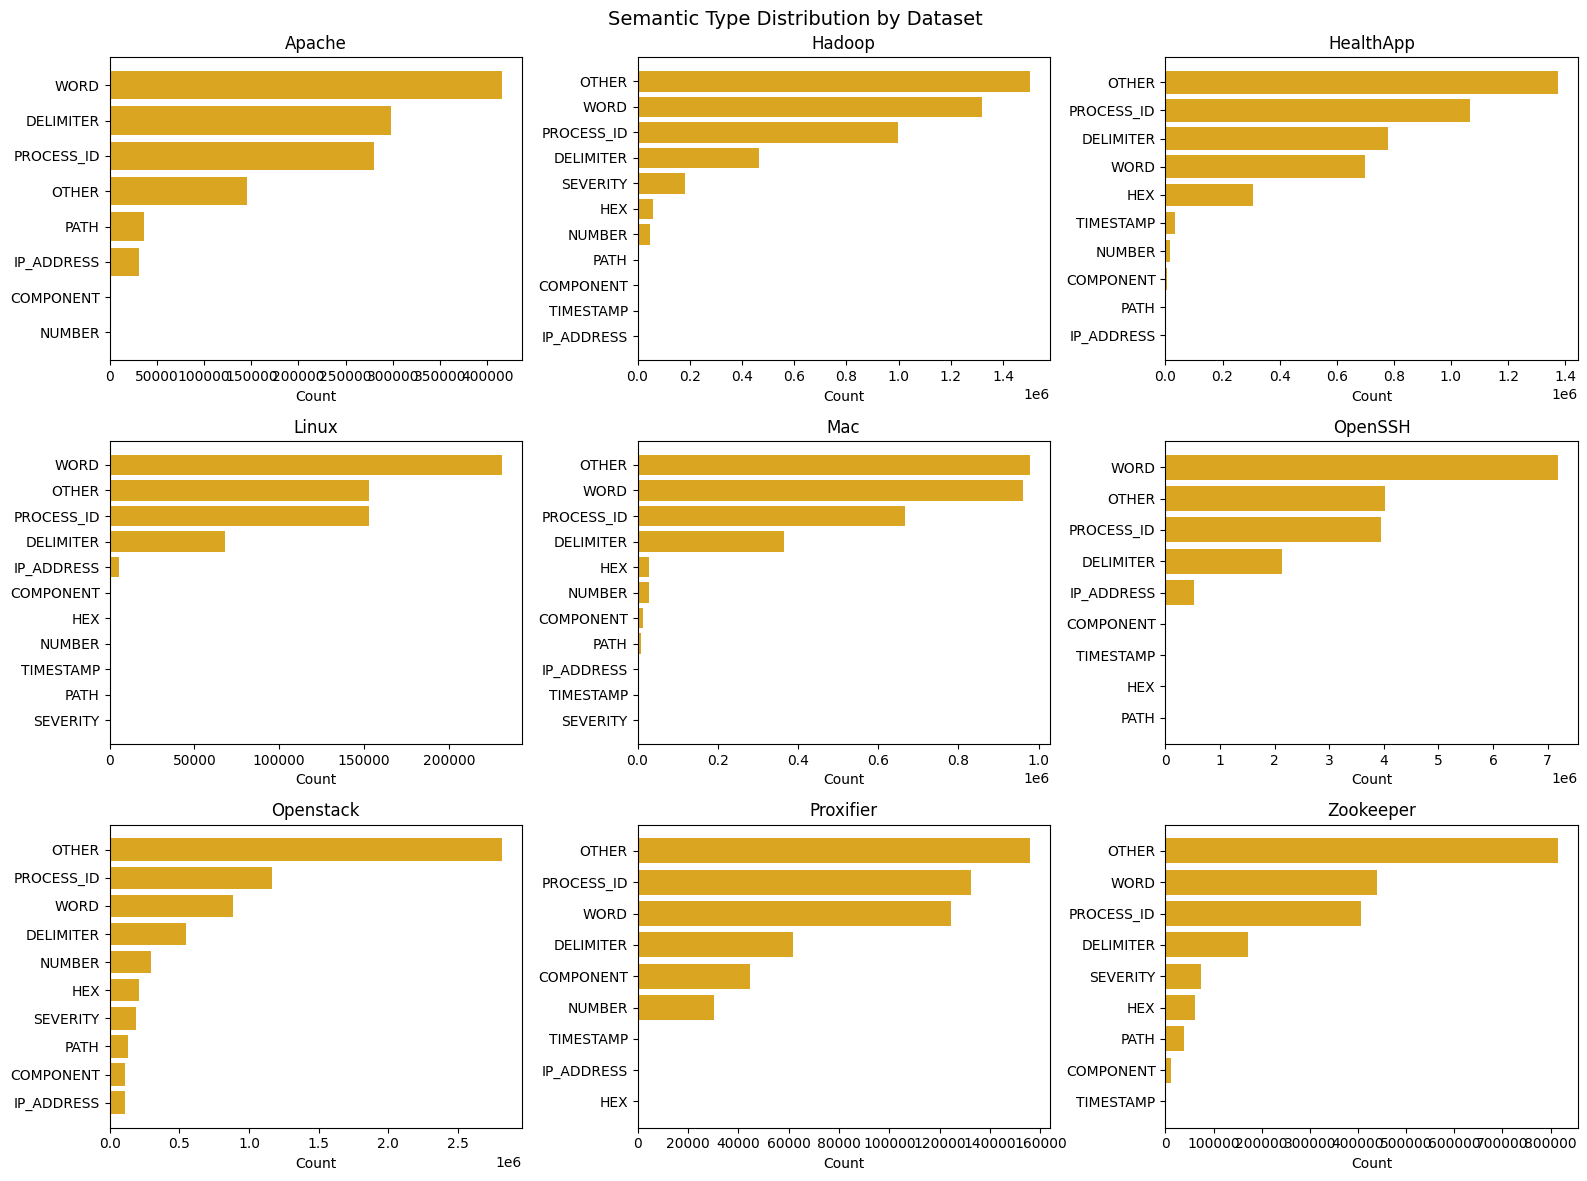

In [14]:
# Analyze semantic type distribution for all datasets and visualize results as a summary table and bar chart
type_distributions = {}

for name, classified_logs in classified_datasets.items():
    type_counts = Counter()
    for log in classified_logs:
        for token, token_type in log:
            type_counts[token_type] += 1
    type_distributions[name] = type_counts

# Create summary table
all_types = set()
for counts in type_distributions.values():
    all_types.update(counts.keys())
all_types = sorted(all_types)

print("Semantic Type Distribution by Dataset:\n")
header = f"{'Dataset':<12}" + "".join(f"{t:<12}" for t in all_types)
print(header)
print("-" * len(header))

for name in type_distributions:
    row = f"{name:<12}"
    for t in all_types:
        count = type_distributions[name].get(t, 0)
        row += f"{count:<12,}"
    print(row)

# Visualize as bar charts
num_datasets = len(type_distributions)
cols = 3
rows = (num_datasets + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
axes = axes.flatten()

for idx, name in enumerate(type_distributions.keys()):
    ax = axes[idx]
    counts = type_distributions[name]
    
    sorted_types = sorted(counts.items(), key=lambda x: x[1], reverse=True)
    types = [t[0] for t in sorted_types]
    values = [t[1] for t in sorted_types]
    
    ax.barh(types, values, color="goldenrod")
    ax.set_xlabel("Count")
    ax.set_title(f"{name}")
    ax.invert_yaxis()

for idx in range(num_datasets, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("Semantic Type Distribution by Dataset", fontsize=14)
plt.tight_layout()
plt.show()

In [15]:
# Show classification examples from each dataset
print("Classification Examples:\n")

for name, classified_logs in classified_datasets.items():
    if len(classified_logs) > 0:
        sample_log = classified_logs[0]
        original_log = datasets[name][0]
        
        print(f"=== {name} ===")
        print(f"Original: {original_log[:100]}..." if len(original_log) > 100 else f"Original: {original_log}")
        print("Classified tokens:")
        for token, token_type in sample_log[:10]:
            print(f"  {token_type:<12} : {token}")
        if len(sample_log) > 10:
            print(f"  ... and {len(sample_log) - 10} more tokens")
        print()

Classification Examples:

=== Apache ===
Original: [Thu Jun 09 06:07:04 2005] [notice] LDAP: Built with OpenLDAP LDAP SDK
Classified tokens:
  DELIMITER    : [
  WORD         : Thu
  WORD         : Jun
  PROCESS_ID   : 09
  PROCESS_ID   : 06
  OTHER        : :
  PROCESS_ID   : 07
  OTHER        : :
  PROCESS_ID   : 04
  PROCESS_ID   : 2005
  ... and 11 more tokens

=== Hadoop ===
Original: 2015-10-17 21:48:16,337 INFO [main] org.apache.hadoop.metrics2.impl.MetricsConfig: loaded properties...
Classified tokens:
  OTHER        : 2015-10-17
  PROCESS_ID   : 21
  OTHER        : :
  PROCESS_ID   : 48
  OTHER        : :
  PROCESS_ID   : 16
  OTHER        : ,
  PROCESS_ID   : 337
  SEVERITY     : INFO
  DELIMITER    : [
  ... and 8 more tokens

=== HealthApp ===
Original: 20171223-22:15:29:606|Step_LSC|30002312|onStandStepChanged 3579
Classified tokens:
  OTHER        : 20171223-22
  OTHER        : :
  PROCESS_ID   : 15
  OTHER        : :
  PROCESS_ID   : 29
  OTHER        : :
  PROCESS_ID   

### Schema and template extraction

The algorithm looks at each token in a log and checks if it changes (like timestamps, IPs, numbers) or stays the same (like brackets, keywords).
Variable tokens are replaced with placeholders like `<TIMESTAMP>`, while constant tokens stay as it is, creating a template that groups similar logs together.

In [16]:
# Define semantic types are that variable (replaced with placeholders) and which are constant (kept in template)

VARIABLE_TYPES = {
    "TIMESTAMP",
    "IP_ADDRESS", 
    "PROCESS_ID",
    "NUMBER",
    "HEX",
    "BLOCK_ID",
    "PATH",
}

CONSTANT_TYPES = {
    "DELIMITER",
    "SEVERITY",
    "WORD",
    "COMPONENT",
    "OTHER",
}


def extract_template(classified_log):
    template_tokens = []
    
    for token, token_type in classified_log:
        if token_type in VARIABLE_TYPES:
            template_tokens.append(f"<{token_type}>")
        else:
            template_tokens.append(token)
    
    return tuple(template_tokens)


def template_to_string(template):
    return " ".join(template)

In [17]:
# Extract templates 
template_datasets = {}

print("Extracting templates for all datasets...\n")
print(f"{'Dataset':<12} {'Logs':>12} {'Unique Templates':>18}")
print("-" * 45)

for name, classified_logs in classified_datasets.items():
    start = time.time()
    
    templates = []
    for log in classified_logs:
        template = extract_template(log)
        templates.append(template)
    
    unique_templates = len(set(templates))
    elapsed = time.time() - start
    
    template_datasets[name] = templates
    
    print(f"{name:<12} {len(templates):>12,} {unique_templates:>18,}")

print("\nTemplate extraction complete.")

Extracting templates for all datasets...

Dataset              Logs   Unique Templates
---------------------------------------------
Apache             51,978              1,019
Hadoop            179,993             29,618
HealthApp         253,395             62,540
Linux              25,567              3,018
Mac               117,283             19,173
OpenSSH           638,947              6,617
Openstack         189,386            128,699
Proxifier          21,320              2,123
Zookeeper          74,273              2,577

Template extraction complete.


Template Analysis:

Dataset        Total Logs    Templates  Logs/Template   Top Template
--------------------------------------------------------------------
Apache             51,978        1,019           51.0           3.4%
Hadoop            179,993       29,618            6.1           2.9%
HealthApp         253,395       62,540            4.1           0.5%
Linux              25,567        3,018            8.5          21.7%
Mac               117,283       19,173            6.1           3.0%
OpenSSH           638,947        6,617           96.6          11.5%
Openstack         189,386      128,699            1.5           2.1%
Proxifier          21,320        2,123           10.0          19.7%
Zookeeper          74,273        2,577           28.8          14.0%


Top 5 Templates per Dataset:

=== Apache ===
  1. (1,748 logs, 3.4%) [ Sun Jan <PROCESS_ID> <PROCESS_ID> : <PROCESS_ID> : <PROCESS_ID> <PRO...
  2. (1,677 logs, 3.2%) [ Sat Jan <PROCESS_ID> <PROCESS_ID> : <PROCESS_ID> :

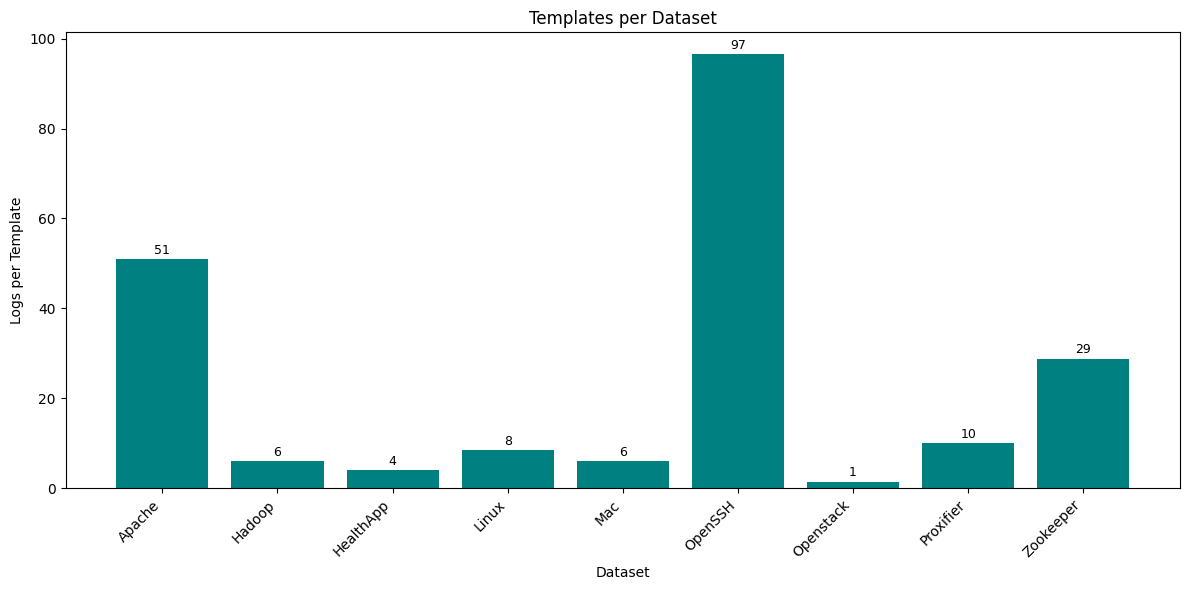

In [18]:
# Analyze template statistics
template_stats = {}

print("Template Analysis:\n")
print(f"{'Dataset':<12} {'Total Logs':>12} {'Templates':>12} {'Logs/Template':>14} {'Top Template':>14}")
print("-" * 68)

for name, templates in template_datasets.items():
    template_counts = Counter(templates)
    total_logs = len(templates)
    num_templates = len(template_counts)
    
    # Compression ratio: how many logs share each template on average
    logs_per_template = total_logs / num_templates
    
    # Top template: what % of logs use the most common template
    top_template_count = template_counts.most_common(1)[0][1]
    top_template_pct = (top_template_count / total_logs) * 100
    
    template_stats[name] = {
        "total_logs": total_logs,
        "num_templates": num_templates,
        "template_counts": template_counts,
        "logs_per_template": logs_per_template,
        "top_template_pct": top_template_pct,
    }
    
    print(f"{name:<12} {total_logs:>12,} {num_templates:>12,} {logs_per_template:>14.1f} {top_template_pct:>13.1f}%")

# Show top 5 templates for each dataset
print("\n\nTop 5 Templates per Dataset:\n")

for name, stats in template_stats.items():
    template_counts = stats["template_counts"]
    total_logs = stats["total_logs"]
    
    print(f"=== {name} ===")
    
    for rank, (template, count) in enumerate(template_counts.most_common(5), 1):
        pct = (count / total_logs) * 100
        template_str = template_to_string(template)
        if len(template_str) > 70:
            template_str = template_str[:70] + "..."
        print(f"  {rank}. ({count:,} logs, {pct:.1f}%) {template_str}")
    
    print()

# Logs per template bar chart 
fig, ax = plt.subplots(figsize=(12, 6))

dataset_names = list(template_stats.keys())
logs_per_template = [template_stats[name]["logs_per_template"] for name in dataset_names]

bars = ax.bar(dataset_names, logs_per_template, color="teal")

ax.set_xlabel("Dataset")
ax.set_ylabel("Logs per Template")
ax.set_title("Templates per Dataset")
ax.set_xticks(range(len(dataset_names)))
ax.set_xticklabels(dataset_names, rotation=45, ha="right")

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.5, f"{height:.0f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

### Compression
Compress logs with schema-based encoding.

Dictionary encoding for templates.

In [19]:
# Template dictionaries for compression (Maps each unique template to an integer ID)

template_dicts = {}

for name, stats in template_stats.items():
    template_counts = stats["template_counts"]
    
    # Sort by frequency
    sorted_templates = [t for t, _ in template_counts.most_common()]
    
    template_to_id = {template: idx for idx, template in enumerate(sorted_templates)}
    id_to_template = {idx: template for template, idx in template_to_id.items()}
    
    template_dicts[name] = {
        "template_to_id": template_to_id,
        "id_to_template": id_to_template,
    }

print(f"Template dictionaries created for {len(template_dicts)} datasets.")

Template dictionaries created for 9 datasets.


In [20]:
# Constants and Configuration Mapping

# Severity list
SEVERITY_LIST = ["INFO", "WARN", "WARNING", "ERROR", "DEBUG", "FATAL", "TRACE", "NOTICE", "CRITICAL", "SEVERE"]
SEVERITY_TO_ID = {s: i for i, s in enumerate(SEVERITY_LIST)}
SEVERITY_FROM_ID = {i: s for i, s in enumerate(SEVERITY_LIST)}

# Type codes
TYPE_TS = 0    # Timestamp
TYPE_SEV = 1   # Severity
TYPE_IP = 2    # IP Address
TYPE_PATH = 3  # File Path
TYPE_VAR = 4   # Other variable (numbers, block IDs, hex, etc.)
TYPE_RAW = 5   # Unknown - store as raw string


In [21]:
# Timestamp conversion function

def timestamp_to_seconds(ts_string):
    formats = [
        "%Y-%m-%d %H:%M:%S",
        "%Y-%m-%dT%H:%M:%S",
        "%Y-%m-%d %H:%M:%S,%f",
        "%H:%M:%S",
        "%H:%M:%S,%f",
    ]
    
    for fmt in formats:
        try:
            dt = datetime.strptime(ts_string, fmt)
            return int(dt.timestamp()) if dt.year > 1970 else int(dt.hour * 3600 + dt.minute * 60 + dt.second)
        except:
            pass
    
    # In case of numeric timestamp (like 081109 for HHMMSS)
    if ts_string.isdigit() and len(ts_string) == 6:
        try:
            h, m, s = int(ts_string[:2]), int(ts_string[2:4]), int(ts_string[4:6])
            return h * 3600 + m * 60 + s
        except:
            pass
    
    return None

In [22]:
# Compression and Decompression Functions For Templates 
# Instead of storing full template, we build a token dictionary and store templates as lists of token IDs.

def compress_templates(id_to_template):
    # Build token dictionary from all templates
    token_to_id = {}
    for template in id_to_template.values():
        for token in template:
            if token not in token_to_id:
                token_to_id[token] = len(token_to_id)
    
    # Store templates as lists of token IDs
    compressed_templates = {}
    for tid, template in id_to_template.items():
        compressed_templates[tid] = [token_to_id[t] for t in template]
    
    return {
        "tokens": {v: k for k, v in token_to_id.items()},  # id -> token
        "templates": compressed_templates,  # template_id -> [token_ids]
    }


def decompress_templates(compressed_template_data):
    tokens = compressed_template_data["tokens"]
    templates = compressed_template_data["templates"]

    id_to_template = {}
    for tid, token_ids in templates.items():
        id_to_template[int(tid)] = [tokens[str(tok_id)] for tok_id in token_ids]
    
    return id_to_template

In [23]:
# Compress logs separators Function
def compress_separators(all_separators):

    # Build dictionary of unique separator strings
    sep_to_id = {"": 0, " ": 1} # common separators
    next_id = 2
    
    compressed_seps = []
    for log_seps in all_separators:
        log_compressed = []
        for sep in log_seps:
            if sep not in sep_to_id:
                sep_to_id[sep] = next_id
                next_id += 1
            log_compressed.append(sep_to_id[sep])
        compressed_seps.append(log_compressed)
    
    return {
        "sep_dict": {v: k for k, v in sep_to_id.items()},
        "separators": compressed_seps,
    }

In [24]:
# Function Encode tokens and their log values based on its type


def encode_token(token, token_type, ip_dict, path_dict, raw_dict, ts_tracker):
    if token_type == "TIMESTAMP":
        ts = timestamp_to_seconds(token)
        if ts is not None:
            ts_tracker["values"].append(ts)
            ts_tracker["positions"].append(ts_tracker["current_position"])
            return [TYPE_TS, ts, token] 
        else:
            return [TYPE_RAW, token]
    
    elif token_type == "SEVERITY":
        sev_id = SEVERITY_TO_ID.get(token, -1)
        if sev_id >= 0:
            return [TYPE_SEV, sev_id]
        else:
            return [TYPE_RAW, token]
    
    elif token_type == "IP_ADDRESS":
        if token not in ip_dict:
            ip_dict[token] = len(ip_dict)
        return [TYPE_IP, ip_dict[token]]
    
    elif token_type == "PATH":
        if token not in path_dict:
            path_dict[token] = len(path_dict)
        return [TYPE_PATH, path_dict[token]]
    
    elif token_type in {"PROCESS_ID", "NUMBER", "HEX", "BLOCK_ID"}:
        if token not in raw_dict:
            raw_dict[token] = len(raw_dict)
        return [TYPE_VAR, raw_dict[token]]
    
    else:
        # Constant token - not encoded (handled by template)
        return None


def encode_log_values(classified_log, ip_dict, path_dict, raw_dict, ts_tracker):
    log_values = []

    for token, token_type in classified_log:
        ts_tracker["current_position"] = (ts_tracker["log_idx"], len(log_values))
        
        encoded = encode_token(token, token_type, ip_dict, path_dict, raw_dict, ts_tracker)
        if encoded is not None:
            log_values.append(encoded)
    
    return log_values


In [25]:
# Delta Encoding Function (for timestamps)

def delta_encode_timestamps(all_values, ts_tracker):

    raw_timestamps = ts_tracker["values"]
    positions = ts_tracker["positions"]
    
    if not raw_timestamps:
        return None
    
    baseline = raw_timestamps[0]
    
    # Calculate deltas
    delta_timestamps = [0]
    for i in range(1, len(raw_timestamps)):
        delta_timestamps.append(raw_timestamps[i] - raw_timestamps[i-1])
    
    # Update values in place with deltas
    for i, (log_idx, value_idx) in enumerate(positions):
        all_values[log_idx][value_idx][1] = delta_timestamps[i]
    
    return baseline

In [26]:
# Main Compression Function where all components are combined, Map each log to its template ID, encode variable values, apply delta encoding to timestamps, compress template dictionary and separators.

def compress_dataset(name, classified_logs, templates, template_dict, separators):
    template_to_id = template_dict["template_to_id"]
    
    # Dictionaries for variable values
    ip_dict = {}
    path_dict = {}
    raw_dict = {}
    
    # Timestamp tracking for delta encoding
    ts_tracker = {
        "values": [],
        "positions": [],
        "log_idx": 0,
        "current_position": None,
    }
    
    # Encode each log
    template_ids = []
    all_values = []
    
    for log_idx, (classified_log, template) in enumerate(zip(classified_logs, templates)):
        ts_tracker["log_idx"] = log_idx
        template_ids.append(template_to_id[template])
        log_values = encode_log_values(classified_log, ip_dict, path_dict, raw_dict, ts_tracker)
        all_values.append(log_values)
    
    # Apply delta encoding to timestamps
    baseline = delta_encode_timestamps(all_values, ts_tracker)
    
    # Build reverse dictionaries for decompression
    id_to_ip = {v: k for k, v in ip_dict.items()}
    id_to_path = {v: k for k, v in path_dict.items()}
    id_to_raw = {v: k for k, v in raw_dict.items()}
    
    # Compress template dictionary and separators
    compressed_templates = compress_templates(template_dict["id_to_template"])
    compressed_seps = compress_separators(separators)
    
    return {
        "template_ids": template_ids,
        "values": all_values,
        "timestamp_baseline": baseline,
        "templates": compressed_templates,
        "id_to_ip": id_to_ip,
        "id_to_path": id_to_path,
        "id_to_raw": id_to_raw,
        "separators": compressed_seps,
    }


In [27]:
# Function raw log size
def get_original_size(logs):
    text = "\n".join(logs)
    return len(text.encode("utf-8"))


# Gzip compression function
def compress_with_gzip(logs): 
    text = "\n".join(logs)
    data = text.encode("utf-8")
    start = time.time()
    compressed = gzip.compress(data, compresslevel=9)
    elapsed = time.time() - start
    return len(compressed), elapsed



In [28]:
# Bzip2 compression function
def compress_with_bzip2(logs): 
    text = "\n".join(logs)
    data = text.encode("utf-8")
    start = time.time()
    compressed = bz2.compress(data, compresslevel=9)
    elapsed = time.time() - start
    return len(compressed), elapsed

In [29]:
# Lzma compression function
def compress_with_lzma(logs): 
    text = "\n".join(logs)
    data = text.encode("utf-8")
    start = time.time()
    compressed = lzma.compress(data, preset=9)
    elapsed = time.time() - start
    return len(compressed), elapsed


In [30]:

# Zstd compression function to raw logs without schema extraction
def compress_with_zstd_raw(logs):
    text = "\n".join(logs)
    data = text.encode("utf-8")
    cctx = zstd.ZstdCompressor(level=19)
    start = time.time()
    compressed = cctx.compress(data)
    elapsed = time.time() - start
    return len(compressed), elapsed

In [31]:
def prepare_for_msgpack(data):
    """Convert data to msgpack-compatible format (tuples to lists, etc.)."""
    if isinstance(data, dict):
        # Convert tuple keys to strings for id_to_template
        result = {}
        for k, v in data.items():
            if isinstance(k, tuple):
                result[str(k)] = prepare_for_msgpack(v)
            else:
                result[k] = prepare_for_msgpack(v)
        return result
    elif isinstance(data, (list, tuple)):
        return [prepare_for_msgpack(item) for item in data]
    else:
        return data

In [32]:
# Logpress compression function
def compress_with_logpress(compressed_data):
    """Compress structured data with msgpack + zstd."""
    start = time.time()
    # Convert to msgpack-compatible format
    msgpack_data = prepare_for_msgpack(compressed_data)
    packed = msgpack.packb(msgpack_data, use_bin_type=True)
    cctx = zstd.ZstdCompressor(level=19)
    compressed = cctx.compress(packed)
    elapsed = time.time() - start
    return compressed, len(compressed), elapsed

In [33]:
# LogPress Save Compressed logs Function
def save_logpress_compressed(datasets, classified_datasets, template_datasets, 
                             template_dicts, separator_datasets, output_dir="compressed"):
    OUTPUT_DIR = Path(output_dir)
    OUTPUT_DIR.mkdir(exist_ok=True)
    
    summary = {}
    for name in datasets.keys():
        compressed_data = compress_dataset(
            name, classified_datasets[name], template_datasets[name],
            template_dicts[name], separator_datasets[name]
        )
        compressed_bytes, size_bytes, elapsed = compress_with_logpress(compressed_data)
        
        output_path = OUTPUT_DIR / f"{name}.logpress"
        with open(output_path, "wb") as f:
            f.write(compressed_bytes)
        
        summary[name] = {
            "path": str(output_path),
            "size_kb": size_bytes / 1024,
            "size_bytes": size_bytes,
            "compression_time": elapsed
        }
    
    print(f"Saved {len(summary)} files to {OUTPUT_DIR}/")
    return summary


In [ ]:
# Compress all datasets
compression_results = {}

for name in datasets.keys():
    logs = datasets[name]
    
    original_size = get_original_size(logs)
    gzip_size, gzip_time = compress_with_gzip(logs)
    bzip2_size, bzip2_time = compress_with_bzip2(logs)
    lzma_size, lzma_time = compress_with_lzma(logs)
    zstd_raw_size, zstd_raw_time = compress_with_zstd_raw(logs)
    
    # LogPress includes schema extraction time
    schema_start = time.time()
    compressed_data = compress_dataset(
        name,
        classified_datasets[name],
        template_datasets[name],
        template_dicts[name],
        separator_datasets[name]
    )
    schema_time = time.time() - schema_start
    _, logpress_size, logpress_compress_time = compress_with_logpress(compressed_data)
    logpress_time = schema_time + logpress_compress_time
    
    compression_results[name] = {
        "original": original_size,
        "gzip": gzip_size,
        "bzip2": bzip2_size,
        "lzma": lzma_size,
        "zstd_raw": zstd_raw_size,
        "logpress": logpress_size,
        "gzip_time": gzip_time,
        "bzip2_time": bzip2_time,
        "lzma_time": lzma_time,
        "zstd_raw_time": zstd_raw_time,
        "logpress_time": logpress_time,
    }
    

summary = save_logpress_compressed(datasets,classified_datasets,template_datasets,template_dicts,separator_datasets,output_dir="compressed")

print(f"\nLogPress Compression Summary:")
print(f"  Total files saved: {len(summary)} folder")
print(f"  Total compressed size: {sum(info['size_kb'] for info in summary.values()):.1f} KB")
print(f"  Average compression time: {sum(info['compression_time'] for info in summary.values()) / len(summary):.2f}s per dataset")

print("Compressing all datasets with other tools for comparison vs LogPress\n")
print(f"{'Dataset':<12} {'Original':>10} {'Gzip':>10} {'Bzip2':>10} {'LZMA':>10} {'Zstd':>10} {'LogPress':>10}")
print("-" * 74)    


Compressing all datasets with multiple methods...

Dataset        Original       Gzip      Bzip2       LZMA       Zstd   LogPress
--------------------------------------------------------------------------
Saved 9 files to compressed/

LogPress Compression Summary:
  Total files saved: 9
  Total compressed size: 12912.0 KB
  Average compression time: 7.01s per dataset


In [37]:
# Calculate compression ratios
print("\n\nCompression Ratios (Original / Compressed):\n")
print(f"{'Dataset':<12} {'Gzip':>10} {'Bzip2':>10} {'LZMA':>10} {'Zstd':>10} {'LogPress':>10}")
print("-" * 64)

for name, results in compression_results.items():
    orig = results["original"]
    print(f"{name:<12} {orig/results['gzip']:>9.1f}x {orig/results['bzip2']:>9.1f}x {orig/results['lzma']:>9.1f}x {orig/results['zstd_raw']:>9.1f}x {orig/results['logpress']:>9.1f}x")

# Total compression ratios
total = {k: sum(r[k] for r in compression_results.values()) for k in ["original", "gzip", "bzip2", "lzma", "zstd_raw", "logpress"]}
print("-" * 64)
print(f"{'TOTAL':<12} {total['original']/total['gzip']:>9.1f}x {total['original']/total['bzip2']:>9.1f}x {total['original']/total['lzma']:>9.1f}x {total['original']/total['zstd_raw']:>9.1f}x {total['original']/total['logpress']:>9.1f}x")




Compression Ratios (Original / Compressed):

Dataset            Gzip      Bzip2       LZMA       Zstd   LogPress
----------------------------------------------------------------
Apache            21.2x      29.2x      28.5x      28.9x      23.1x
Hadoop            14.7x      22.5x      25.7x      29.4x      23.3x
HealthApp         10.8x      13.7x      15.6x      16.2x      11.0x
Linux             11.2x      14.7x      20.0x      19.6x      11.4x
Mac               11.7x      18.0x      24.3x      26.6x      18.0x
OpenSSH           16.6x      22.3x      20.8x      24.2x      22.1x
Openstack         12.2x      15.3x      15.7x      16.3x      12.0x
Proxifier         15.7x      23.6x      21.0x      20.9x      13.7x
Zookeeper         25.9x      36.1x      29.8x      38.8x      29.1x
----------------------------------------------------------------
TOTAL             14.0x      18.9x      19.7x      21.5x      16.5x


In [38]:
# Compression time
print("\n\nCompression Time (seconds):\n")
print(f"{'Dataset':<12} {'Gzip':>10} {'Bzip2':>10} {'LZMA':>10} {'Zstd':>10} {'LogPress':>10}")
print("-" * 64)

for name, results in compression_results.items():
    print(f"{name:<12} {results['gzip_time']:>9.2f}s {results['bzip2_time']:>9.2f}s {results['lzma_time']:>9.2f}s {results['zstd_raw_time']:>9.2f}s {results['logpress_time']:>9.2f}s")

total_times = {
    "gzip": sum(r["gzip_time"] for r in compression_results.values()),
    "bzip2": sum(r["bzip2_time"] for r in compression_results.values()),
    "lzma": sum(r["lzma_time"] for r in compression_results.values()),
    "zstd_raw": sum(r["zstd_raw_time"] for r in compression_results.values()),
    "logpress": sum(r["logpress_time"] for r in compression_results.values()),
}
print("-" * 64)
print(f"{'TOTAL':<12} {total_times['gzip']:>9.2f}s {total_times['bzip2']:>9.2f}s {total_times['lzma']:>9.2f}s {total_times['zstd_raw']:>9.2f}s {total_times['logpress']:>9.2f}s")



Compression Time (seconds):

Dataset            Gzip      Bzip2       LZMA       Zstd   LogPress
----------------------------------------------------------------
Apache            0.08s      0.53s      0.74s      1.75s      4.88s
Hadoop            0.41s      3.18s      4.90s     25.71s     14.43s
HealthApp         0.68s      1.78s      8.08s     18.25s     18.32s
Linux             0.07s      0.21s      0.54s      0.89s      0.90s
Mac               0.21s      1.52s      3.56s     11.17s      7.49s
OpenSSH           1.82s      6.99s     21.51s     44.90s     35.78s
Openstack         0.65s      7.80s     17.49s     50.15s     26.53s
Proxifier         0.05s      0.42s      0.48s      1.06s      1.23s
Zookeeper         0.26s      1.30s      1.96s      9.84s      2.78s
----------------------------------------------------------------
TOTAL             4.22s     23.71s     59.24s    163.72s    112.34s


In [39]:
# Plots Visualization of compression results

dataset_names = list(compression_results.keys())
methods = ["gzip", "bzip2", "lzma", "zstd_raw", "logpress"]
colors = ["#4A4A4A", "#1ABC9C", "#E67E22", "#3498DB", "#95A5A6"]
method_labels = ["Gzip", "Bzip2", "LZMA", "Zstd (raw)", "LogPress"]

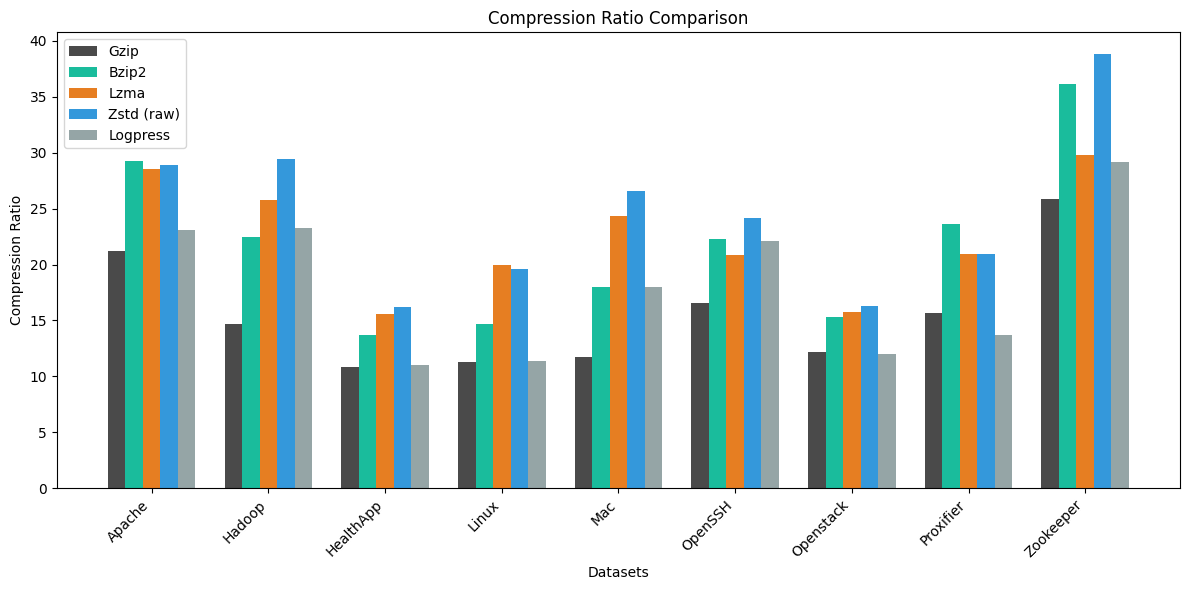

In [40]:
# Chart 1: Compression Ratios comparison

fig, ax1 = plt.subplots(figsize=(12, 6))
x = np.arange(len(dataset_names))
width = 0.15

for i, (method, color) in enumerate(zip(methods, colors)):
    ratios = [compression_results[name]["original"] / compression_results[name][method] for name in dataset_names]
    offset = (i - 2) * width
    label = "Zstd (raw)" if method == "zstd_raw" else method.capitalize()
    ax1.bar(x + offset, ratios, width, label=label, color=color)

ax1.set_xlabel("Datasets")
ax1.set_ylabel("Compression Ratio")
ax1.set_title("Compression Ratio Comparison")
ax1.set_xticks(x)
ax1.set_xticklabels(dataset_names, rotation=45, ha="right")
ax1.legend(loc="upper left")
plt.tight_layout()
plt.show()

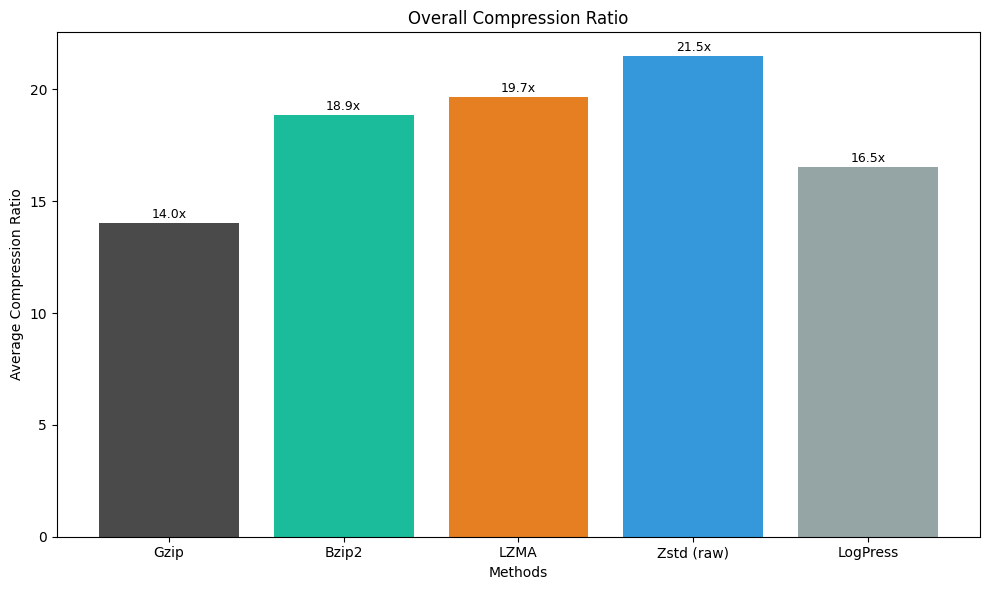

In [41]:
# Chart 2: Average compression ratio per method
fig, ax2 = plt.subplots(figsize=(10, 6))
avg_ratios = []
for method in methods:
    total_orig = sum(compression_results[name]["original"] for name in dataset_names)
    total_comp = sum(compression_results[name][method] for name in dataset_names)
    avg_ratios.append(total_orig / total_comp)

bars = ax2.bar(method_labels, avg_ratios, color=colors)
ax2.set_xlabel("Methods")
ax2.set_ylabel("Average Compression Ratio")
ax2.set_title("Overall Compression Ratio")

for bar, ratio in zip(bars, avg_ratios):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             f"{ratio:.1f}x", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

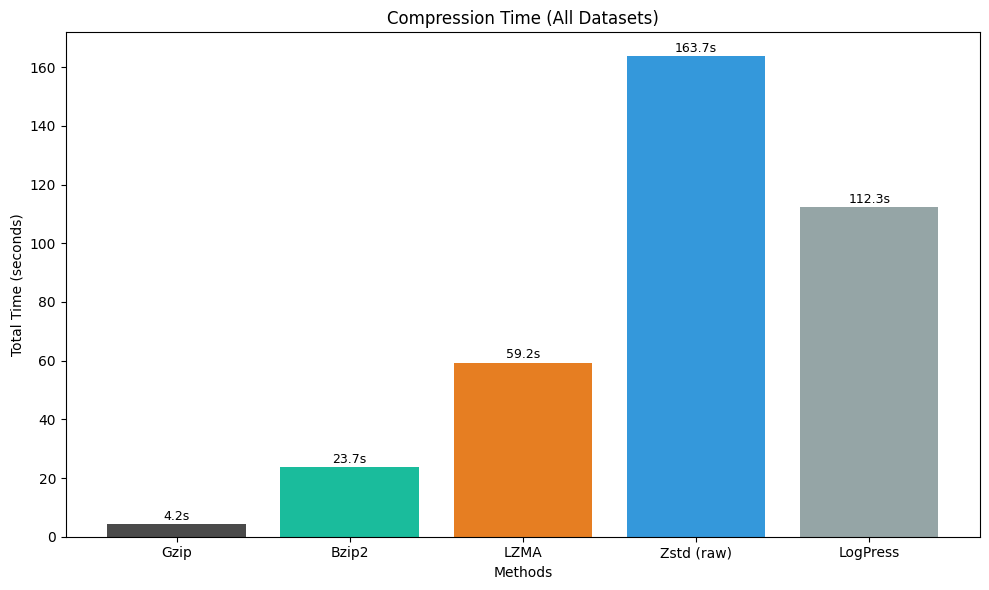

In [42]:
# Chart 3: Total compression time per method
fig, ax3 = plt.subplots(figsize=(10, 6))
total_times = [
    sum(compression_results[name]["gzip_time"] for name in dataset_names),
    sum(compression_results[name]["bzip2_time"] for name in dataset_names),
    sum(compression_results[name]["lzma_time"] for name in dataset_names),
    sum(compression_results[name]["zstd_raw_time"] for name in dataset_names),
    sum(compression_results[name]["logpress_time"] for name in dataset_names),
]

bars = ax3.bar(method_labels, total_times, color=colors)
ax3.set_xlabel("Methods")
ax3.set_ylabel("Total Time (seconds)")
ax3.set_title("Compression Time (All Datasets)")

for bar, t in zip(bars, total_times):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f"{t:.1f}s", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

In [43]:
# Summary 
print("Compression Performance Summary\n")
print(f"  {'-'*70}")
print(f"  {'Method':<15} {'Ratio':>10} {'Time':>10} {'Speed':>12}")
print(f"  {'-'*70}")

speed_efficiency = []
for i, method in enumerate(method_labels):
    # Speed efficiency: compression ratio per second
    efficiency = avg_ratios[i] / total_times[i] if total_times[i] > 0 else 0
    speed_efficiency.append(efficiency)
    print(f"  {method:<15} {avg_ratios[i]:>9.1f}x {total_times[i]:>9.1f}s {efficiency:>11.3f}x/s")

print(f"  {'-'*70}")

# Best performers by category
best_ratio_idx = avg_ratios.index(max(avg_ratios))
best_speed_idx = total_times.index(min(total_times))
best_efficiency_idx = speed_efficiency.index(max(speed_efficiency))

print(f"  Best Compression Ratio:    {method_labels[best_ratio_idx]} ({avg_ratios[best_ratio_idx]:.1f}x)")
print(f"  Fastest Compression:       {method_labels[best_speed_idx]} ({total_times[best_speed_idx]:.1f}s)")
print(f"  Best Efficiency (ratio/s): {method_labels[best_efficiency_idx]} ({speed_efficiency[best_efficiency_idx]:.3f}x/s)")

# LogPress  analysis
print(f"  {'-'*70}")
logpress_idx = 4
best_baseline_ratio = max(avg_ratios[:4])
best_baseline_idx = avg_ratios[:4].index(best_baseline_ratio)

ratio_improvement = ((avg_ratios[logpress_idx] - best_baseline_ratio) / best_baseline_ratio) * 100
time_comparison = ((total_times[logpress_idx] - total_times[best_baseline_idx]) / total_times[best_baseline_idx]) * 100

print(f"LogPress Analysis vs Best Baseline ({method_labels[best_baseline_idx]}):")
print(f"        Ratio difference:  {ratio_improvement:+.1f}% {'✓' if ratio_improvement > 0 else '✗'}")
print(f"        Time difference:   {time_comparison:+.1f}% {'✓' if time_comparison < 0 else '✗'}")
print(f"        Efficiency:        {speed_efficiency[logpress_idx]:.3f}x/s")



Compression Performance Summary

  ----------------------------------------------------------------------
  Method               Ratio       Time        Speed
  ----------------------------------------------------------------------
  Gzip                 14.0x       4.2s       3.323x/s
  Bzip2                18.9x      23.7s       0.795x/s
  LZMA                 19.7x      59.2s       0.332x/s
  Zstd (raw)           21.5x     163.7s       0.131x/s
  LogPress             16.5x     112.3s       0.147x/s
  ----------------------------------------------------------------------
  Best Compression Ratio:    Zstd (raw) (21.5x)
  Fastest Compression:       Gzip (4.2s)
  Best Efficiency (ratio/s): Gzip (3.323x/s)
  ----------------------------------------------------------------------
LogPress Analysis vs Best Baseline (Zstd (raw)):
        Ratio difference:  -23.0% ✗
        Time difference:   -31.4% ✓
        Efficiency:        0.147x/s
